# Part 5 - Guardrail Pipeline

This notebook demonstrates a 3-layer moderation pipeline on 1,000 evaluation examples:
1. Layer 1: regex input filter
2. Layer 2: calibrated model decisions
3. Layer 3: human review queue for uncertain cases

Artifacts:
- pipeline.py with ModerationPipeline.predict(text)
- Layer distribution plot
- Auto-action metrics (F1, precision, recall)
- Review queue toxic/non-toxic breakdown
- Threshold band comparison for 0.4-0.6 vs alternatives

In [1]:
!pip install -q transformers torch scikit-learn pandas matplotlib seaborn

In [2]:
import zipfile

with zipfile.ZipFile("best_mitigated_model_part_4.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

from pipeline import ModerationPipeline, input_filter

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
print("Imports loaded.")

Imports loaded.


In [4]:
import importlib
import pipeline as pipeline_module
importlib.reload(pipeline_module)

from pipeline import ModerationPipeline, _TransformerScoreEstimator
print(_TransformerScoreEstimator.__mro__)
print("estimator_type:", getattr(_TransformerScoreEstimator, "_estimator_type", None))

(<class 'pipeline._TransformerScoreEstimator'>, <class 'sklearn.base.ClassifierMixin'>, <class 'sklearn.base.BaseEstimator'>, <class 'sklearn.utils._estimator_html_repr._HTMLDocumentationLinkMixin'>, <class 'sklearn.utils._metadata_requests._MetadataRequester'>, <class 'object'>)
estimator_type: classifier


In [5]:
# Step 1: Paths and configuration
EVAL_PATH = "eval_subset_20k.csv"
MODEL_DIR = "best_mitigated_model_part_4"

BAND_LOW = 0.4
BAND_HIGH = 0.6
N_DEMO = 1000

print(f"Eval path: {EVAL_PATH}")
print(f"Model dir: {MODEL_DIR}")

Eval path: eval_subset_20k.csv
Model dir: best_mitigated_model_part_4


In [6]:
# Step 2: Load data, ensure labels, and sample 1,000 examples for demo.
eval_df = pd.read_csv(EVAL_PATH)
if "label" not in eval_df.columns:
    eval_df["label"] = (eval_df["toxic"] >= 0.5).astype(int)

# Preserve original row identity so calibration holdout can exclude demo rows correctly.
demo_idx = eval_df.sample(n=min(N_DEMO, len(eval_df)), random_state=SEED).index
demo_df = eval_df.loc[demo_idx].copy().reset_index(drop=True)

print(f"Total eval rows: {len(eval_df):,}")
print(f"Demo rows: {len(demo_df):,}")
print(demo_df[["comment_text", "label"]].head(2))

Total eval rows: 20,000
Demo rows: 1,000
                                        comment_text  label
0  I watched one show and stopped, it was like wa...      0
1  The state is in the hurt locker.  The legislat...      0


In [7]:
# Step 3: Initialize pipeline and fit isotonic calibration.
pipeline = ModerationPipeline(
    model_dir=MODEL_DIR,
    allow_threshold=BAND_LOW,
    block_threshold=BAND_HIGH,
)

# Fit calibrator on held-out rows not in demo sample to avoid circular evaluation.
calib_df = eval_df.drop(index=demo_idx, errors="ignore")
if len(calib_df) < 1000:
    calib_df = eval_df.sample(n=min(3000, len(eval_df)), random_state=SEED + 7)
else:
    calib_df = calib_df.sample(n=min(5000, len(calib_df)), random_state=SEED + 7)

pipeline.fit_calibrator(
    texts=calib_df["comment_text"].fillna("").astype(str).tolist(),
    labels=calib_df["label"].astype(int).tolist(),
    cv=3,
)

print(f"Calibrator fit rows: {len(calib_df):,}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Calibrator fit rows: 5,000


In [8]:
# Step 4: Run pipeline on 1,000 comments and collect structured decisions.
# Layer 1: input_filter may immediately block with a category.
# Layer 2: calibrated model returns allow/block when confidence is outside the uncertainty band.
# Layer 3: calibrated model returns review when confidence is inside the uncertainty band.
records = []
for _, row in demo_df.iterrows():
    text = "" if pd.isna(row["comment_text"]) else str(row["comment_text"])
    out = pipeline.predict(text)
    records.append({
        "comment_text": text,
        "label": int(row["label"]),
        "decision": out.get("decision"),
        "layer": out.get("layer"),
        "confidence": float(out.get("confidence", np.nan)),
        "category": out.get("category", None),
    })

results_df = pd.DataFrame(records)
results_df.head(3)

,comment_text,label,decision,layer,confidence,category
0,"I watched one show and stopped, it was like wa...",0,allow,model,0.161988,None
1,The state is in the hurt locker. The legislat...,0,allow,model,0.008655,None
2,It's people like Obama that label..........it ...,0,allow,model,0.009899,None


In [9]:
# Step 5: Category-level counts for input filter triggers (required).
input_hits = results_df[results_df["layer"] == "input_filter"]
category_counts = input_hits["category"].value_counts(dropna=False).rename_axis("category").reset_index(name="count")

print("Input filter blocks by category")
display(category_counts)

Input filter blocks by category


,category,count
0,dehumanization,1


,layer,count,fraction
0,Layer 2: Calibrated Model,979,0.979
1,Layer 3: Human Review,20,0.020
2,Layer 1: Input Filter,1,0.001


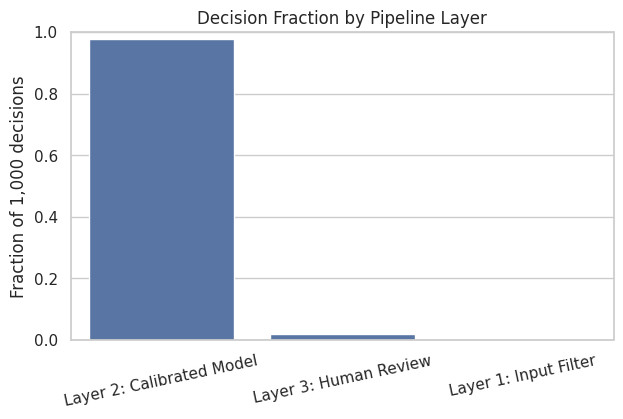

In [10]:
# Step 6: Fraction handled by each layer (Layer 1/2/3) + plot.
# Layer mapping for analysis:
# - input_filter -> Layer 1: Input Filter
# - model + review decision -> Layer 3: Human Review queue
# - model + allow/block decision -> Layer 2: Calibrated Model auto-action
def layer_bucket(row):
    if row["layer"] == "input_filter":
        return "Layer 1: Input Filter"
    if row["decision"] == "review":
        return "Layer 3: Human Review"
    return "Layer 2: Calibrated Model"

results_df["layer_bucket"] = results_df.apply(layer_bucket, axis=1)
layer_dist = results_df["layer_bucket"].value_counts().rename_axis("layer").reset_index(name="count")
layer_dist["fraction"] = layer_dist["count"] / len(results_df)

display(layer_dist)

plt.figure(figsize=(7, 4))
sns.barplot(data=layer_dist, x="layer", y="fraction")
plt.ylim(0, 1)
plt.title("Decision Fraction by Pipeline Layer")
plt.ylabel("Fraction of 1,000 decisions")
plt.xlabel("")
plt.xticks(rotation=12)
plt.show()

In [11]:
# Step 7: Auto-action quality for Layer 2 confident decisions only.
# This excludes Layer 1 (rule-based blocks) and Layer 3 (review queue).
auto_layer2 = results_df[(results_df["layer"] == "model") & (results_df["decision"] != "review")].copy()

auto_layer2["pred_label"] = (auto_layer2["decision"] == "block").astype(int)

auto_metrics = {
    "n_auto_layer2": len(auto_layer2),
    "f1": f1_score(auto_layer2["label"], auto_layer2["pred_label"]) if len(auto_layer2) > 0 else np.nan,
    "precision": precision_score(auto_layer2["label"], auto_layer2["pred_label"], zero_division=0) if len(auto_layer2) > 0 else np.nan,
    "recall": recall_score(auto_layer2["label"], auto_layer2["pred_label"], zero_division=0) if len(auto_layer2) > 0 else np.nan,
}

display(pd.DataFrame([auto_metrics]))

,n_auto_layer2,f1,precision,recall
0,979,0.677165,0.754386,0.614286


In [12]:
# Step 8: Review queue toxic/non-toxic breakdown.
review_df = results_df[results_df["decision"] == "review"].copy()
review_breakdown = review_df["label"].value_counts(dropna=False).rename_axis("label").reset_index(name="count")
review_breakdown["fraction"] = review_breakdown["count"] / max(len(review_df), 1)

print(f"Review queue size: {len(review_df):,}")
display(review_breakdown)

Review queue size: 20


,label,count,fraction
0,1,11,0.55
1,0,9,0.45


## Key Question Analysis: Is 0.4-0.6 the Right Review Band?

In [13]:
# Step 9: Compare default vs alternative uncertainty bands.
# Required alternatives: 0.45-0.55 and 0.3-0.7
bands = [
    (0.4, 0.6, "0.4-0.6"),
    (0.45, 0.55, "0.45-0.55"),
    (0.3, 0.7, "0.3-0.7"),
]

# Cache model confidences for non-filtered rows to evaluate different bands consistently.
results_band = results_df.copy()
needs_model = results_band["layer"] != "input_filter"

if needs_model.any():
    texts_nm = results_band.loc[needs_model, "comment_text"].tolist()
    conf_nm = pipeline.calibrator.predict_proba(texts_nm)[:, 1]
    results_band.loc[needs_model, "model_conf"] = conf_nm
else:
    results_band["model_conf"] = np.nan

rows = []
for low, high, name in bands:
    tmp = results_band.copy()

    # Keep input filter decisions fixed. Recompute only model-layer decisions by band.
    mask_model = tmp["layer"] != "input_filter"
    tmp.loc[mask_model & (tmp["model_conf"] >= high), "decision_band"] = "block"
    tmp.loc[mask_model & (tmp["model_conf"] <= low), "decision_band"] = "allow"
    tmp.loc[mask_model & (tmp["model_conf"] > low) & (tmp["model_conf"] < high), "decision_band"] = "review"
    tmp.loc[~mask_model, "decision_band"] = "block"

    review_n = int((tmp["decision_band"] == "review").sum())

    auto_layer2 = tmp[mask_model & (tmp["decision_band"] != "review")].copy()
    if len(auto_layer2) > 0:
        auto_layer2["pred_label"] = (auto_layer2["decision_band"] == "block").astype(int)
        auto_acc = accuracy_score(auto_layer2["label"], auto_layer2["pred_label"])
        auto_f1 = f1_score(auto_layer2["label"], auto_layer2["pred_label"])
    else:
        auto_acc = np.nan
        auto_f1 = np.nan

    rows.append({
        "band": name,
        "review_volume": review_n,
        "review_fraction": review_n / len(tmp),
        "auto_layer2_n": len(auto_layer2),
        "auto_layer2_accuracy": auto_acc,
        "auto_layer2_f1": auto_f1,
    })

band_compare_df = pd.DataFrame(rows)
display(band_compare_df)

,band,review_volume,review_fraction,auto_layer2_n,auto_layer2_accuracy,auto_layer2_f1
0,0.4-0.6,20,0.020,979,0.958121,0.677165
1,0.45-0.55,7,0.007,992,0.951613,0.671233
2,0.3-0.7,43,0.043,956,0.965481,0.702703


Is 0.4–0.6 the right choice?
- Yes, it remains a strong balanced choice. It keeps human review low at 20 items (2.0%) while maintaining solid automated performance: auto-action accuracy 95.81% and F1 0.677.

What happens if you narrow to 0.45–0.55?
- Human review volume drops sharply from 20 to 7 (2.0% to 0.7%), so reviewer workload is much lower.
- But automation quality declines:
- Auto-action accuracy: 95.81% to 95.16% (down 0.65 percentage points)
- Auto-action F1: 0.677 to 0.671 (down 0.006)

What happens if you widen to 0.3–0.7?
- Human review volume rises from 20 to 43 (2.0% to 4.3%), so reviewer workload more than doubles.
- Automation quality improves:
- Auto-action accuracy: 95.81% to 96.55% (up 0.74 percentage points)
- Auto-action F1: 0.677 to 0.703 (up 0.026)

Final choice
- Choose 0.4–0.6 as the default threshold band.
- Reason: 0.45–0.55 minimizes review load but weakens auto-decision quality; 0.3–0.7 improves quality but at a large review-cost increase. The 0.4–0.6 band offers the best practical trade-off between moderation quality and human-review capacity.